In [1]:
import matplotlib.pyplot as plt
import numpy as np

# define inputs, weights and bias

In [2]:
x1=1.0
x2=0.5
w1 = 0.7
w2 = -0.3
b = 0.1

In [3]:
z = (x1*w1) + (x2*w2) + b

print(f"x1 = {x1} , x2 = {x2} \n w1= {w1} , w2 = {w2} , bias = {b}")

print(f"z = x1w1 + x2w2 + b = {z:.4f}")

x1 = 1.0 , x2 = 0.5 
 w1= 0.7 , w2 = -0.3 , bias = 0.1
z = x1w1 + x2w2 + b = 0.6500


# i) Binary Step Function

In [4]:
def binary_step(z):
    if z>=0:
        return 1
    else:
        return 0

# ii) Linear Function

In [5]:
def linear(z):
    return z

# iii) Sigmoid Function

In [6]:
def sigmoid(z):
  return 1 / (1+ np.exp(-z))

# iv) tanh Function tanh= (e^z-e^-z) / (e^z + e^-z)

In [7]:
def tanh_activation(z):
    return np.tanh(z)

# v) Relu Function

In [8]:
def relu(z):
    return max(0,z)

# vi) Leaky ReLU function

In [9]:
def Leaky_Relu_function(z,alpha=0.01):
    if z >= 0:
        return z
    else:
        return alpha*z

# vii) Parametric ReLU Function

In [10]:
def parameric_relu(z,alpha=0.1):
    if z>=0:
        return z
    else:
        return alpha*z

#  viii) Softmax function Zi=e^(Zj) /  Σ {e^(Zj)}

In [29]:
def softmax(z):
    z=np.asarray(z, dtype=float)
    shifted = z-np.max(z)
    
    exp_values=np.exp(shifted)
    return exp_values / np.sum(exp_values)

In [30]:
alpha_leaky = 0.01
alpha_prelu=0.1

results = [
    ("Binary Step" , binary_step(z)),
    ("Linear", linear(z)),
    ("Sigmoid", sigmoid(z)),
    ("Tanh", tanh_activation(z)),
    ("ReLU", relu(z)),
    (f"Leaky ReLU (alpha={alpha_leaky})", Leaky_Relu_function(z,alpha_leaky)),
    (f"Parametric ReLU (alpha={alpha_prelu})", parameric_relu(z,alpha_prelu)),
    ("Softmax (single scaler)", softmax([z])[0])
]

In [31]:
print(f"Weighted sum z = {z:.4f}\n")
for name, y in results:
    y = np.asarray(y).item()
    print(f"{name:32s} y={y:.6f}")

Weighted sum z = 0.6500

Binary Step                      y=1.000000
Linear                           y=0.650000
Sigmoid                          y=0.657010
Tanh                             y=0.571670
ReLU                             y=0.650000
Leaky ReLU (alpha=0.01)          y=0.650000
Parametric ReLU (alpha=0.1)      y=0.650000
Softmax (single scaler)          y=1.000000


In [32]:
for name , y in results:
    print(name , type(y), y)

Binary Step <class 'int'> 1
Linear <class 'float'> 0.6499999999999999
Sigmoid <class 'numpy.float64'> 0.6570104626734988
Tanh <class 'numpy.float64'> 0.5716699660851171
ReLU <class 'float'> 0.6499999999999999
Leaky ReLU (alpha=0.01) <class 'float'> 0.6499999999999999
Parametric ReLU (alpha=0.1) <class 'float'> 0.6499999999999999
Softmax (single scaler) <class 'numpy.float64'> 1.0


In [33]:
results

[('Binary Step', 1),
 ('Linear', 0.6499999999999999),
 ('Sigmoid', np.float64(0.6570104626734988)),
 ('Tanh', np.float64(0.5716699660851171)),
 ('ReLU', 0.6499999999999999),
 ('Leaky ReLU (alpha=0.01)', 0.6499999999999999),
 ('Parametric ReLU (alpha=0.1)', 0.6499999999999999),
 ('Softmax (single scaler)', np.float64(1.0))]

# Softmax classification for a two-class output

In [34]:
two_class_output = [z, 0.0]
two_class_probabilities = np.array(softmax(two_class_output))

print(f"Output : {two_class_output}")
print(f"Sum of probabilities : {two_class_probabilities} ")
print(f"Sum of probabilities : {two_class_probabilities.sum()} ")

Output : [0.6499999999999999, 0.0]
Sum of probabilities : [0.65701046 0.34298954] 
Sum of probabilities : 1.0 


# Visualize the activation functions

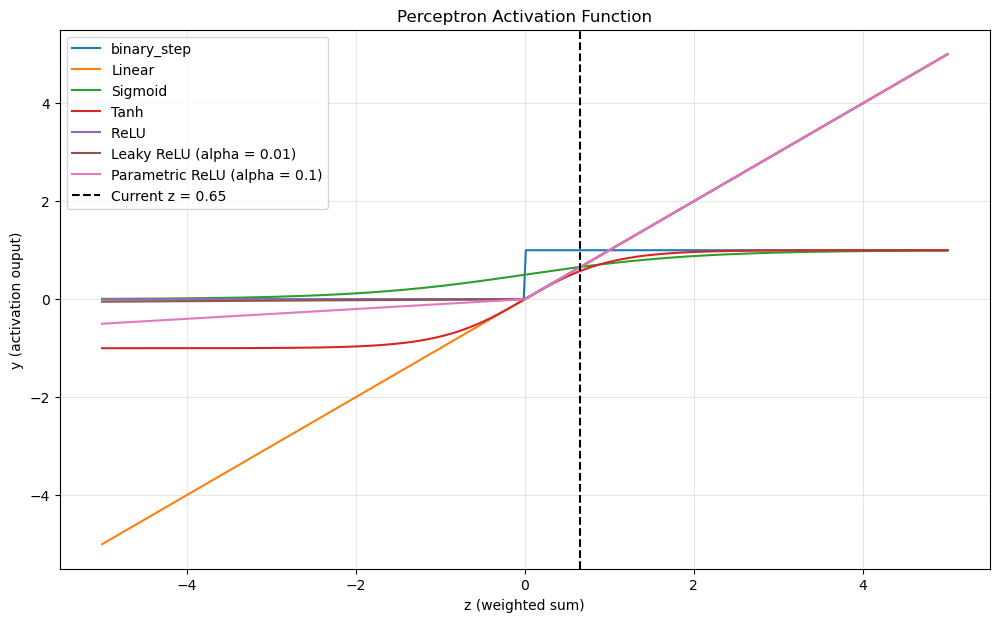

In [44]:
z_values = np.linspace(-5,5,400)
alpha = 0.1

plt.figure(figsize=(12,7))

plt.plot(z_values , [binary_step(v) for v in z_values], label= "binary_step")
plt.plot(z_values, z_values, label="Linear")
plt.plot(z_values, 1 / (1+np.exp(-z_values)), label="Sigmoid")
plt.plot(z_values, np.tanh(z_values), label="Tanh")
plt.plot(z_values, np.maximum(0, z_values), label="ReLU ")

plt.plot(z_values, np.where(z_values >=0 , z_values , 0.01*z_values),label="Leaky ReLU (alpha = 0.01)")
plt.plot(z_values, np.where(z_values >=0 , z_values , 0.1*z_values),label="Parametric ReLU (alpha = 0.1)")


plt.axvline(z, color="black", linestyle="--", label = f"Current z = {z:.2f}")
plt.xlabel("z (weighted sum)")
plt.ylabel("y (activation ouput)")

plt.title("Perceptron Activation Function")

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

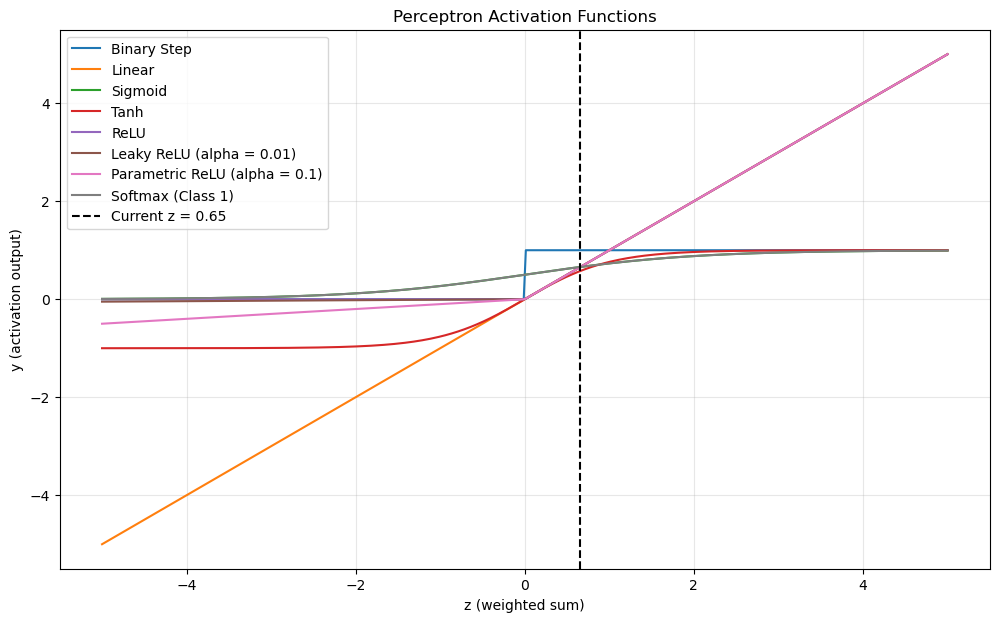

In [45]:
z_values = np.linspace(-5, 5, 400)
alpha = 0.1

plt.figure(figsize=(12,7))

plt.plot(z_values, [binary_step(v) for v in z_values],
         label="Binary Step")

plt.plot(z_values, z_values,
         label="Linear")

plt.plot(z_values, 1 / (1 + np.exp(-z_values)),
         label="Sigmoid")

plt.plot(z_values, np.tanh(z_values),
         label="Tanh")

plt.plot(z_values, np.maximum(0, z_values),
         label="ReLU")

plt.plot(z_values,
         np.where(z_values >= 0, z_values, 0.01*z_values),
         label="Leaky ReLU (alpha = 0.01)")

plt.plot(z_values,
         np.where(z_values >= 0, z_values, 0.1*z_values),
         label="Parametric ReLU (alpha = 0.1)")


# Softmax for 2 classes: [z, 0]
softmax_class1 = [
    softmax([v, 0.0])[0]
    for v in z_values
]

plt.plot(
    z_values,
    softmax_class1,
    label="Softmax (Class 1)"
)


plt.axvline(z, color="black", linestyle="--",
            label=f"Current z = {z:.2f}")

plt.xlabel("z (weighted sum)")
plt.ylabel("y (activation output)")

plt.title("Perceptron Activation Functions")

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()